In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("matching_training_dataset.csv")

In [3]:
df.head()

,request_id,requested_service,requested_problem,customer_latitude,customer_longitude,worker_id,worker_name,worker_skill,worker_experience,worker_rating,...,worker_latitude,worker_longitude,distance_km,skill_match,distance_score,experience_score,rating_score,availability_score,workload_score,successful_match
0,R0001,Cleaning,Bathroom Cleaning,28.637382,76.949141,W0918,Sunil Yadav,Cleaning,2,3.3,...,28.580210,76.899841,7.97,1,0.111483,0.10,0.66,1,0.7,1
1,R0001,Cleaning,Bathroom Cleaning,28.637382,76.949141,W0387,Ravi Agarwal,Cleaning,1,3.2,...,29.131972,77.779809,97.80,1,0.010121,0.05,0.64,1,0.7,1
2,R0001,Cleaning,Bathroom Cleaning,28.637382,76.949141,W0799,Pankaj Gupta,Cleaning,14,4.8,...,29.174896,77.646124,90.42,1,0.010939,0.70,0.96,1,0.4,1
3,R0001,Cleaning,Bathroom Cleaning,28.637382,76.949141,W0404,Vikas Sharma,Cleaning,6,3.2,...,28.889871,77.045030,29.59,1,0.032690,0.30,0.64,1,0.3,1
4,R0001,Cleaning,Bathroom Cleaning,28.637382,76.949141,W0674,Arun Gupta,Cleaning,8,3.5,...,28.553709,76.811313,16.36,1,0.057604,0.40,0.70,1,0.8,1


In [4]:
y = df["successful_match"]

In [5]:
features = [
    "requested_service",
    "requested_problem",
    "worker_skill",
    "worker_experience",
    "worker_rating",
    "worker_workload",
    "worker_availability",
    "distance_km",
    "skill_match"
]

X = df[features]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
categorical_features = [
    "requested_service",
    "requested_problem",
    "worker_skill"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [8]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [9]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [10]:
y_pred = model.predict(X_test_processed)

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.61075


In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.57      0.57      1773
           1       0.65      0.64      0.65      2227

    accuracy                           0.61      4000
   macro avg       0.61      0.61      0.61      4000
weighted avg       0.61      0.61      0.61      4000



In [13]:
print(confusion_matrix(y_test, y_pred))

[[1012  761]
 [ 796 1431]]


In [14]:
y_probability = model.predict_proba(X_test_processed)[:, 1]

print(y_probability[:10])

[0.925 0.545 0.76  0.845 0.875 0.795 0.335 0.865 0.4   0.165]


In [15]:
probability_percent = y_probability * 100

print(probability_percent[:10])

[92.5 54.5 76.  84.5 87.5 79.5 33.5 86.5 40.  16.5]


In [16]:
results = X_test.copy()

results["actual_match"] = y_test.values
results["match_probability"] = y_probability
results["match_percentage"] = (y_probability * 100).round(2)

results.head(10)

,requested_service,requested_problem,worker_skill,worker_experience,worker_rating,worker_workload,worker_availability,distance_km,skill_match,actual_match,match_probability,match_percentage
12060,Plumbing,Bathroom Repair,Plumbing,11,4.3,8,1,90.77,1,1,0.925,92.5
4730,Plumbing,Water Tank,Plumbing,16,4.0,6,0,16.24,1,1,0.545,54.5
15303,Electrical,Switch Repair,Electrical,7,3.9,0,1,43.31,1,1,0.760,76.0
9702,Painting,Room Painting,Painting,11,3.3,4,1,55.84,1,1,0.845,84.5
10805,Cleaning,Deep Cleaning,Cleaning,11,3.1,10,1,46.74,1,1,0.875,87.5
19110,Electrical,Wiring,Electrical,3,4.6,2,1,30.20,1,0,0.795,79.5
15050,Cleaning,Bathroom Cleaning,Cleaning,14,3.0,7,0,17.29,1,1,0.335,33.5
4625,Painting,Room Painting,Painting,6,3.4,8,1,35.40,1,0,0.865,86.5
16753,Carpentry,Woodwork,Carpentry,17,4.3,6,1,64.33,1,0,0.400,40.0
2878,Carpentry,Furniture Repair,Electrical,4,3.9,2,0,65.76,0,0,0.165,16.5


In [17]:
results.sort_values(
    "match_probability",
    ascending=False
).head(10)

,requested_service,requested_problem,worker_skill,worker_experience,worker_rating,worker_workload,worker_availability,distance_km,skill_match,actual_match,match_probability,match_percentage
16393,Cleaning,Kitchen Cleaning,Cleaning,9,4.1,1,1,64.34,1,0,0.990,99.0
14082,Painting,Wall Painting,Painting,18,4.9,4,1,35.97,1,1,0.990,99.0
2076,Cleaning,Deep Cleaning,Cleaning,19,4.1,3,1,69.95,1,1,0.990,99.0
6114,Carpentry,Furniture Repair,Carpentry,11,3.8,1,1,78.81,1,0,0.985,98.5
7425,Cleaning,Deep Cleaning,Cleaning,20,3.9,0,1,18.87,1,1,0.985,98.5
6112,Carpentry,Furniture Repair,Carpentry,18,3.9,0,1,75.90,1,1,0.985,98.5
4514,Plumbing,Tap Repair,Plumbing,20,4.5,4,1,93.03,1,1,0.985,98.5
9561,Carpentry,Woodwork,Carpentry,11,3.3,9,1,48.51,1,1,0.985,98.5
11931,Gardening,Tree Trimming,Gardening,14,4.8,3,1,6.89,1,1,0.980,98.0
17123,Cleaning,Bathroom Cleaning,Cleaning,15,4.9,6,1,19.19,1,0,0.980,98.0


In [18]:
import joblib

joblib.dump(model, "worker_matching_model.pkl")
joblib.dump(preprocessor, "worker_matching_preprocessor.pkl")

['worker_matching_preprocessor.pkl']

In [ ]:
workers = pd.read_csv("worker_master_dataset.csv")

workers.head()

In [24]:
workers = pd.read_csv("worker_master_dataset.csv")

workers.head()

,worker_id,name,skill,experience,rating,workload,availability,latitude,longitude
0,W0001,Arun Mishra,Painting,17,3.7,8,1,28.508227,77.272012
1,W0002,Arun Gupta,Carpentry,6,3.4,1,1,28.613568,77.107222
2,W0003,Mohit Kumar,Gardening,2,3.8,7,1,28.701854,77.306128
3,W0004,Mohit Verma,Carpentry,12,4.6,6,1,28.496527,77.609808
4,W0005,Vikas Joshi,Electrical,6,4.3,3,1,28.829180,77.532576


In [25]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) *
        np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [26]:
def recommend_workers(
    service,
    problem,
    customer_lat,
    customer_lon,
    top_n=5
):
    
    # Copy worker data
    candidates = workers.copy()
    
    # Calculate distance
    candidates["distance_km"] = haversine_distance(
        customer_lat,
        customer_lon,
        candidates["latitude"],
        candidates["longitude"]
    )
    
    candidates["distance_km"] = candidates["distance_km"].round(2)
    
    # Skill match
    candidates["skill_match"] = (
        candidates["skill"] == service
    ).astype(int)
    
    # Keep only available workers
    candidates = candidates[
        candidates["availability"] == 1
    ].copy()
    
    # Create features required by model
    candidates["availability_score"] = (
        candidates["availability"]
    )
    
    candidates["experience_score"] = (
        candidates["experience"] / 20
    )
    
    candidates["rating_score"] = (
        candidates["rating"] / 5
    )
    
    candidates["workload_score"] = (
        1 - candidates["workload"] / 10
    )
    
    candidates["distance_score"] = (
        1 / (1 + candidates["distance_km"])
    )
    
    # Create input for model
    X_new = pd.DataFrame({
        "requested_service": service,
        "requested_problem": problem,
        "worker_skill": candidates["skill"],
        "worker_experience": candidates["experience"],
        "worker_rating": candidates["rating"],
        "worker_workload": candidates["workload"],
        "worker_availability": candidates["availability"],
        "distance_km": candidates["distance_km"],
        "skill_match": candidates["skill_match"]
    })
    
    # Apply same preprocessing used during training
    X_new_processed = preprocessor.transform(X_new)
    
    # Predict probability
    candidates["match_probability"] = (
        model.predict_proba(X_new_processed)[:, 1]
    )
    
    # Convert to percentage
    candidates["match_percentage"] = (
        candidates["match_probability"] * 100
    ).round(2)
    
    # Sort best → worst
    candidates = candidates.sort_values(
        "match_probability",
        ascending=False
    )
    
    return candidates.head(top_n)

In [27]:
recommendations = recommend_workers(
    service="Plumbing",
    problem="Pipe Leakage",
    customer_lat=28.61,
    customer_lon=77.20,
    top_n=5
)

In [28]:
recommendations[[
    "worker_id",
    "name",
    "skill",
    "experience",
    "rating",
    "distance_km",
    "match_percentage"
]]

,worker_id,name,skill,experience,rating,distance_km,match_percentage
406,W0407,Ravi Mishra,Plumbing,9,4.9,47.72,99.5
48,W0049,Pankaj Gupta,Plumbing,18,3.4,72.39,98.5
62,W0063,Karan Joshi,Plumbing,4,5.0,34.75,98.0
198,W0199,Rajesh Verma,Plumbing,3,4.9,25.77,97.5
660,W0661,Anil Gupta,Plumbing,9,3.8,51.73,95.5


In [29]:
test1 = recommend_workers(
    service="Plumbing",
    problem="Pipe Leakage",
    customer_lat=28.61,
    customer_lon=77.20,
    top_n=5
)

test1[[
    "worker_id",
    "name",
    "skill",
    "rating",
    "distance_km",
    "match_percentage"
]]

,worker_id,name,skill,rating,distance_km,match_percentage
406,W0407,Ravi Mishra,Plumbing,4.9,47.72,99.5
48,W0049,Pankaj Gupta,Plumbing,3.4,72.39,98.5
62,W0063,Karan Joshi,Plumbing,5.0,34.75,98.0
198,W0199,Rajesh Verma,Plumbing,4.9,25.77,97.5
660,W0661,Anil Gupta,Plumbing,3.8,51.73,95.5


In [30]:
test2 = recommend_workers(
    service="Electrical",
    problem="Fan Repair",
    customer_lat=28.80,
    customer_lon=77.30,
    top_n=5
)

test2[[
    "worker_id",
    "name",
    "skill",
    "rating",
    "distance_km",
    "match_percentage"
]]

,worker_id,name,skill,rating,distance_km,match_percentage
973,W0974,Deepak Mishra,Electrical,4.7,47.39,99.0
291,W0292,Anil Gupta,Electrical,4.4,37.25,97.5
570,W0571,Deepak Kumar,Electrical,4.7,50.77,97.5
659,W0660,Vikas Verma,Electrical,4.2,43.77,97.0
944,W0945,Karan Gupta,Electrical,4.2,53.58,97.0


In [31]:
test3 = recommend_workers(
    service="Cleaning",
    problem="Deep Cleaning",
    customer_lat=28.65,
    customer_lon=77.10,
    top_n=5
)

test3[[
    "worker_id",
    "name",
    "skill",
    "rating",
    "distance_km",
    "match_percentage"
]]

,worker_id,name,skill,rating,distance_km,match_percentage
927,W0928,Anil Verma,Cleaning,4.0,32.66,98.5
816,W0817,Arun Patel,Cleaning,4.7,55.72,98.5
479,W0480,Manoj Sharma,Cleaning,3.8,51.32,97.5
607,W0608,Vivek Singh,Cleaning,4.2,40.69,97.5
824,W0825,Karan Yadav,Cleaning,4.6,81.74,97.0


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.61075
Precision: 0.6528284671532847
Recall   : 0.6425684777727885
F1 Score : 0.6476578411405295


In [33]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1012  761]
 [ 796 1431]]


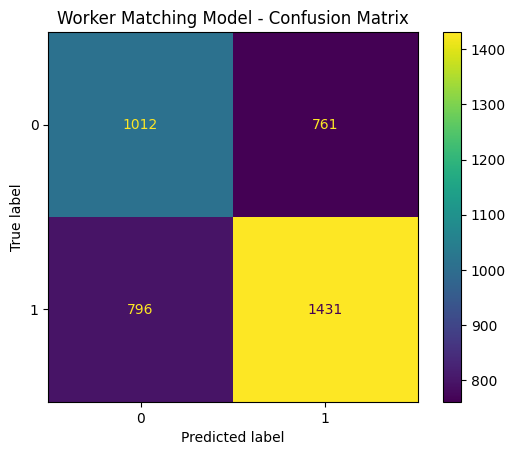

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title("Worker Matching Model - Confusion Matrix")
plt.show()

In [35]:
feature_names = preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})
importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)
importance_df.head(15)

,feature,importance
40,remainder__distance_km,0.379791
37,remainder__worker_rating,0.127824
36,remainder__worker_experience,0.122980
38,remainder__worker_workload,0.097535
41,remainder__skill_match,0.081984
39,remainder__worker_availability,0.019131
31,cat__worker_skill_Cleaning,0.007171
33,cat__worker_skill_Gardening,0.006762
34,cat__worker_skill_Painting,0.006743
32,cat__worker_skill_Electrical,0.006721


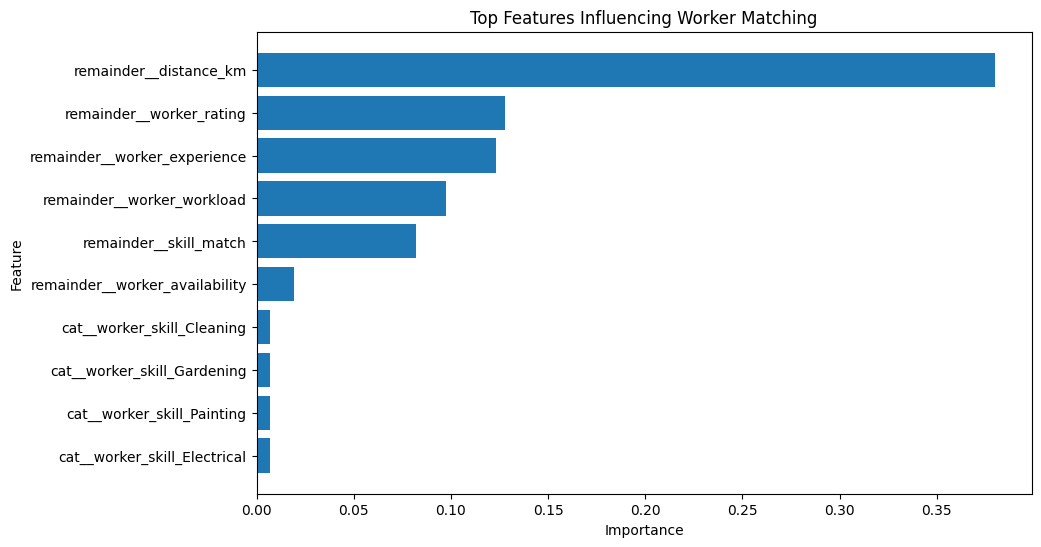

In [36]:
plt.figure(figsize=(10, 6))

top_features = importance_df.head(10)

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Features Influencing Worker Matching")
plt.gca().invert_yaxis()

plt.show()